In [1]:
pip install bertopic sentence-transformers statsmodels arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 58.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn
import re
import math
import statistics

from collections import defaultdict  # dictionary with default values
from itertools import combinations  # generates all possible unique combinations of length; we will need it for generating all unique pairs of keywords
from collections import Counter  # counting occurrences of elements

import nltk
from nltk.tokenize import word_tokenize  # text tokenization
from nltk.corpus import stopwords  # stopwords list
nltk.download('stopwords')  # neccesary for stopwords
from nltk.probability import FreqDist
from nltk.tokenize import RegexpTokenizer
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP  # dimensionality reduction technique for visualization or preprocessing
from hdbscan import HDBSCAN  # density-based clustering algorithm for finding clusters of varying shapes/sizes
from bertopic import BERTopic  # topic modeling library based on transformers and clustering
from bertopic.vectorizers import ClassTfidfTransformer  # improves topic representations using class-based TF-IDF
from bertopic.representation import KeyBERTInspired  # representation model for fine-tuning topic descriptions

import statsmodels.api as sm # for linear regression model, OLS estimation
import statsmodels.stats.diagnostic as smd # for Breusch-Godfrey test
from arch.unitroot import PhillipsPerron # for performing PP test
from statsmodels.tsa.stattools import kpss # for performing KPSS test

from pathlib import Path

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
sun = pd.read_csv("/content/drive/MyDrive/Narrative Economics/sun_tech_articles.csv")

In [5]:
sun.head(5)

,Unnamed: 0,publication_date,title,content,matched_keywords,matched_categories,pub_date,source
0,0,2024-10-17 21:44:45+00:00,Our love of fish and chips goes back almost a ...,OUR love of fish and chips goes back almost a ...,['new technologies'],['technology'],2024-10-17 21:44:45+00:00,The Sun
1,1,2024-10-17 12:12:58+00:00,Samsung Black Friday deals 2024: What to expec...,Samsung Black Friday deals 2024: What to expec...,['generative ai'],['ai'],2024-10-17 12:12:58+00:00,The Sun
2,2,2023-12-14 16:31:26+00:00,You might have ‘Neanderthal gene’ as scientist...,You might have ‘Neanderthal gene’ as scientist...,['artificial intelligence'],['ai'],2023-12-14 16:31:26+00:00,The Sun
3,3,2024-10-14 10:12:07+00:00,Sir Keir Starmer tells world’s billionaires he...,Sir Keir Starmer tells world’s billionaires he...,['artificial intelligence'],['ai'],2024-10-14 10:12:07+00:00,The Sun
4,4,2024-10-14 08:17:47+00:00,"Elon Musk IS very, very welcome in Britain, sa...",ELON Musk has not been snubbed by Sir Keir Sta...,['artificial intelligence'],['ai'],2024-10-14 08:17:47+00:00,The Sun


In [6]:
# no empty title found
texts_lengths = [len(text) for text in sun['title']]

print("Min. =", np.round(min(texts_lengths),2))
print("Max. =", np.round(max(texts_lengths),2))
print("Mean =", np.round(statistics.mean(texts_lengths),2))
print("Median =", np.round(statistics.median(texts_lengths),2))
print("Std. dev. =", np.round(statistics.stdev(texts_lengths),2))


Min. = 14
Max. = 208
Mean = 98.1
Median = 101.0
Std. dev. = 20.9


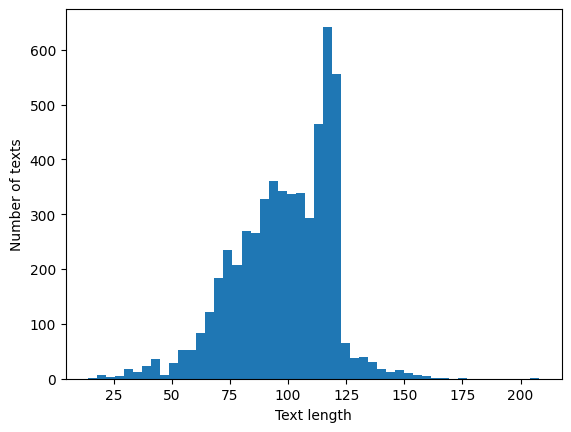

In [7]:
plt.hist(texts_lengths, bins=50)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.show()

In [8]:
# no duplicate found
sun.duplicated().sum()

np.int64(0)

## Text Processing

In [9]:
lemmatiser = nltk.stem.WordNetLemmatizer()
stop_words = set(nltk.corpus.stopwords.words('english'))  # set for O(1) lookup

def clean_text(text):
    if not text or not isinstance(text, str):
        return ''
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters and spaces
    text = text.lower()
    text = re.sub(r'\b\w\b', '', text)        # remove single chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text):
    return word_tokenize(text)

def lemmatize_tokens(tokens):
    return [lemmatiser.lemmatize(token) for token in tokens]

def clean_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

def process_texts_verbose(data):
    # 1. Clean
    cleaned = [clean_text(text) for text in data]

    # 2. Tokenize
    tokenized = [tokenize_text(text) for text in cleaned]
    print(f'After tokenization: {len(set(t for doc in tokenized for t in doc)):,} unique tokens')

    # 3. Lemmatize
    lemmatized = [lemmatize_tokens(doc) for doc in tokenized]
    print(f'After lemmatization: {len(set(t for doc in lemmatized for t in doc)):,} unique tokens')

    # 4. Remove stopwords
    final = [clean_stopwords(doc) for doc in lemmatized]
    print(f'After stopwords: {len(set(t for doc in final for t in doc)):,} unique tokens')

    return final

In [10]:
text_lower = sun["title"].str.lower().tolist()
text_processing = process_texts_verbose(sun['title'])

After tokenization: 9,543 unique tokens
After lemmatization: 8,344 unique tokens
After stopwords: 8,227 unique tokens


In [11]:
def generate_ngrams(tokens, ngram_range=(1,3)):

    all_ngrams = []  # this list will store all generated n-grams

    # loop over each n in the range (e.g., 1, 2, 3)
    for n in range(ngram_range[0], ngram_range[1]+1):
        # create sliding windows of length n
        ngrams = zip(*[tokens[i:] for i in range(n)])  # e.g., for bigrams: [tokens[0:], tokens[1:]]

        # join tokens with underscores to form n-gram strings
        all_ngrams.extend(['_'.join(gram) for gram in ngrams])

    return all_ngrams  # return the complete list of n-grams

texts_with_ngrams = [generate_ngrams(doc, ngram_range=(1,3)) for doc in text_processing]

In [12]:
def compute_tfidf(texts):
    N = len(texts)

    # DF first (need it for IDF)
    df_dict = Counter()
    for doc in texts:
        df_dict.update(set(doc))

    # IDF
    idf_dict = {token: math.log(N / count) for token, count in df_dict.items()}

    # TF + TF-IDF
    tf_docs = []
    tfidf_docs = []
    for doc in texts:
        counts = Counter(doc)
        total = len(doc) or 1
        tf = {w: c / total for w, c in counts.items()}
        tfidf = {w: tf[w] * idf_dict[w] for w in tf}
        tf_docs.append(tf)
        tfidf_docs.append(tfidf)

    df_dict = {token: count / N for token, count in df_dict.items()}

    return tf_docs, df_dict, idf_dict, tfidf_docs

In [13]:
tf_docs, df_dict, idf_dict, tfidf_docs = compute_tfidf(texts_with_ngrams)
df_values = list(df_dict.values())
top25_df = dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)[:25])

In [14]:
for token, df in top25_df.items():
    print(f"{token}: {df:.3f}")

ai: 0.158
new: 0.117
could: 0.091
robot: 0.066
year: 0.057
say: 0.048
expert: 0.048
world: 0.044
get: 0.040
uk: 0.038
reveals: 0.037
human: 0.036
u: 0.036
make: 0.036
million: 0.035
car: 0.034
time: 0.031
warns: 0.030
like: 0.030
iphone: 0.030
people: 0.029
using: 0.029
ha: 0.029
china: 0.029
tech: 0.028


## Clustering

In [15]:
docs_joined = [' '.join(doc) for doc in texts_with_ngrams]

# Vectorize
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(docs_joined)
print(f"TF-IDF matrix: {X.shape}")

TF-IDF matrix: (5516, 10000)


  k= 2 | Inertia: 5,465 | Silhouette: 0.0023
  k= 3 | Inertia: 5,453 | Silhouette: 0.0030
  k= 4 | Inertia: 5,441 | Silhouette: 0.0034
  k= 5 | Inertia: 5,428 | Silhouette: 0.0040
  k= 6 | Inertia: 5,421 | Silhouette: 0.0043
  k= 7 | Inertia: 5,418 | Silhouette: 0.0045
  k= 8 | Inertia: 5,404 | Silhouette: 0.0053
  k= 9 | Inertia: 5,401 | Silhouette: 0.0049
  k=10 | Inertia: 5,388 | Silhouette: 0.0062
  k=11 | Inertia: 5,374 | Silhouette: 0.0072
  k=12 | Inertia: 5,369 | Silhouette: 0.0075
  k=13 | Inertia: 5,366 | Silhouette: 0.0073
  k=14 | Inertia: 5,352 | Silhouette: 0.0081
  k=15 | Inertia: 5,346 | Silhouette: 0.0081
  k=16 | Inertia: 5,342 | Silhouette: 0.0088
  k=17 | Inertia: 5,342 | Silhouette: 0.0083
  k=18 | Inertia: 5,333 | Silhouette: 0.0089
  k=19 | Inertia: 5,323 | Silhouette: 0.0096
  k=20 | Inertia: 5,325 | Silhouette: 0.0095
  k=21 | Inertia: 5,312 | Silhouette: 0.0106
  k=22 | Inertia: 5,309 | Silhouette: 0.0104
  k=23 | Inertia: 5,306 | Silhouette: 0.0104
  k=24 | I

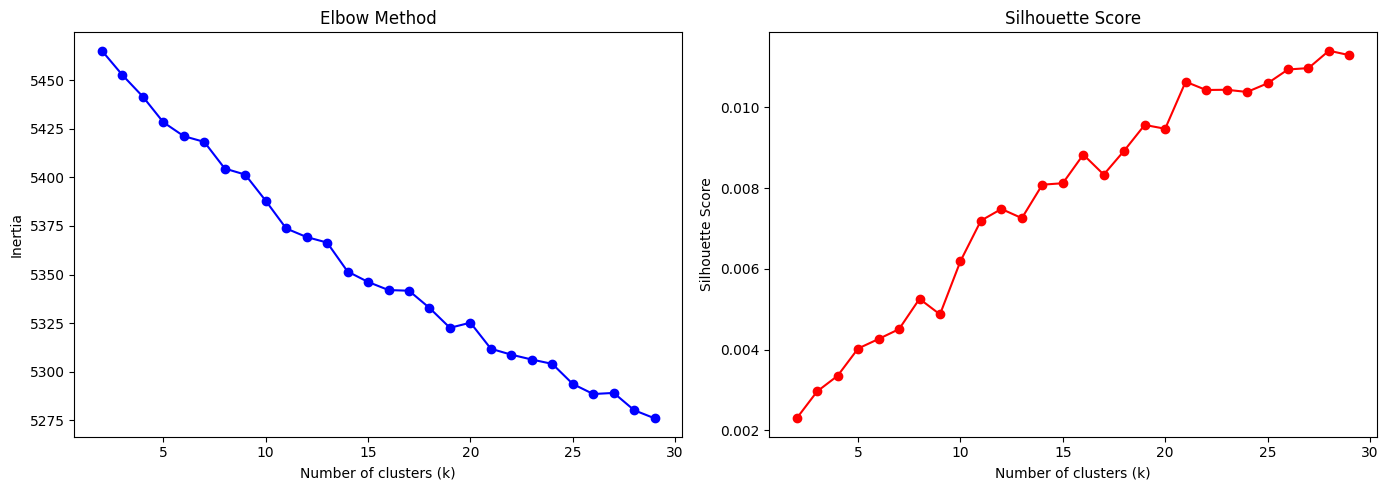


Best k by silhouette: 28 (score: 0.0114)


In [16]:
K_range = range(2, 30)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"  k={k:2d} | Inertia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k} (score: {max(silhouettes):.4f})")

In [17]:
km_final = KMeans(n_clusters=21, random_state=42, n_init=10)
labels = km_final.fit_predict(X)

# Top terms per cluster
terms = vectorizer.get_feature_names_out()
for i in range(21):
    center = km_final.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]
    top_terms = [terms[j] for j in top_idx]
    print(f"\nCluster {i} ({(labels == i).sum():,} articles):")
    print(f"  {', '.join(top_terms)}")


Cluster 0 (1,615 articles):
  star, ha, time, world, covid, putin, using, get, million, one

Cluster 1 (432 articles):
  new, facebook, make, app, instagram, feature, get, ai, show, technology

Cluster 2 (196 articles):
  uk, airport, major, passenger, uk_airport, rule, liquid, major_change, change, ml

Cluster 3 (237 articles):
  iphone, upgrade, android, free, apple, phone, owner, free_upgrade, user, google

Cluster 4 (254 articles):
  robot, sex, sex_robot, human, doll, ai, world, first, humanoid, sex_doll

Cluster 5 (127 articles):
  musk, elon_musk, elon, grime, brain, tesla, neuralink, baby, musk_grime, elon_musk_grime

Cluster 6 (186 articles):
  back, may, theresa, theresa_may, tory, brexit, hammond, labour, get, must

Cluster 7 (279 articles):
  could, ai, new, expert, save, could_save, human, technology, cancer, could_help

Cluster 8 (67 articles):
  league, premier_league, premier, var, champion_league, champion, arsenal, fan, football, season

Cluster 9 (101 articles):
  b

In [18]:
sun['pub_date'] = pd.to_datetime(sun['pub_date'], errors='coerce')

In [20]:
sun['cluster'] = labels
cluster_by_year = sun.groupby([sun['pub_date'].dt.year, 'cluster']).size().unstack(fill_value=0)
cluster_by_year_pct = cluster_by_year.div(cluster_by_year.sum(axis=1), axis=0) * 100

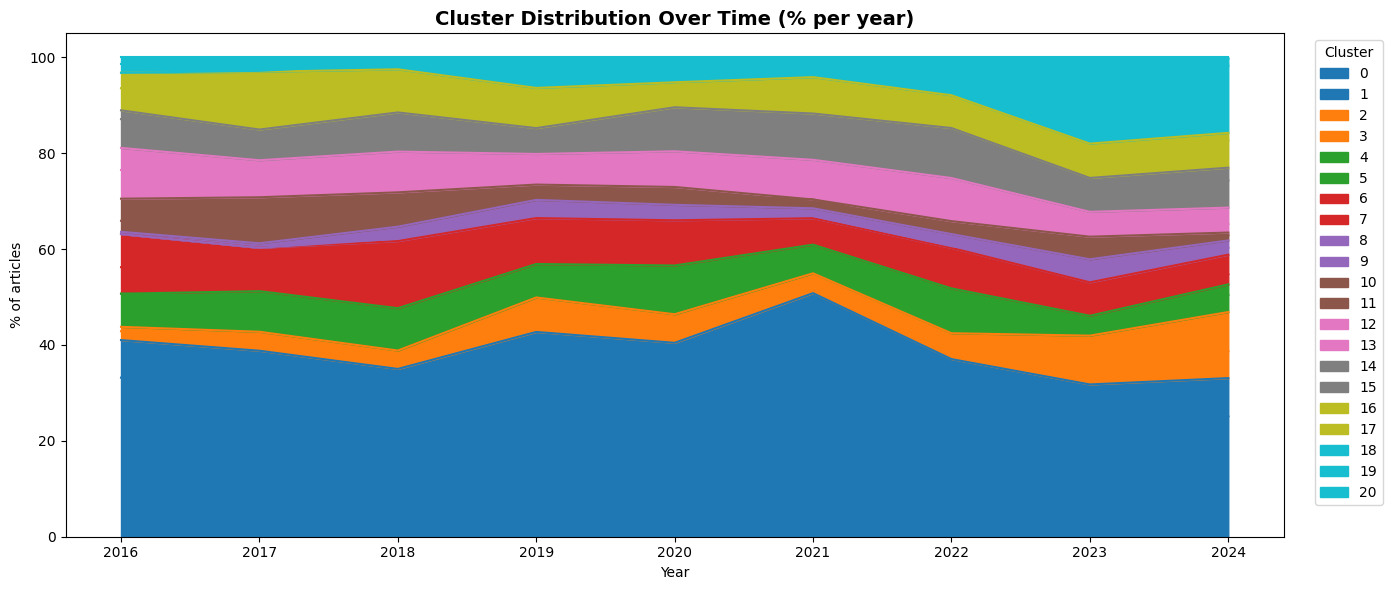

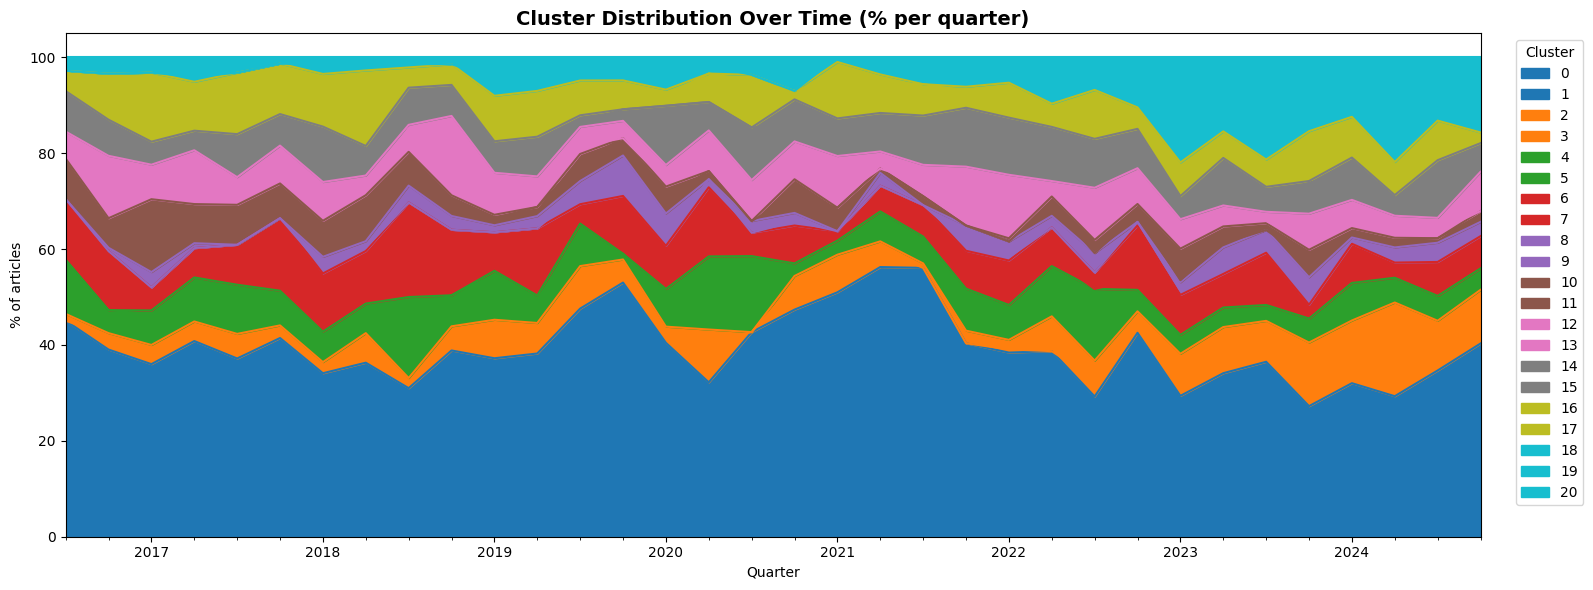

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
cluster_by_year_pct.plot(kind='area', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Cluster Distribution Over Time (% per year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of articles')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

sun['quarter'] = sun['pub_date'].dt.to_period('Q')
cluster_by_q = sun.groupby(['quarter', 'cluster']).size().unstack(fill_value=0)
cluster_by_q_pct = cluster_by_q.div(cluster_by_q.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 6))
cluster_by_q_pct.plot(kind='area', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Cluster Distribution Over Time (% per quarter)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('% of articles')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()




In [22]:
for year in [2017, 2020, 2023, 2024]:
    print(f"\n{'='*60}")
    print(f"YEAR: {year}")
    year_mask = sun['pub_date'].dt.year == year
    for c in range(best_k):
        cluster_docs = sun[year_mask & (sun['cluster'] == c)]
        if len(cluster_docs) == 0:
            continue
        # Get TF-IDF scores for this subset
        idx = cluster_docs.index.tolist()
        subset = X[idx]
        mean_scores = np.asarray(subset.mean(axis=0)).flatten()
        top_idx = mean_scores.argsort()[-5:][::-1]
        top_terms = [terms[j] for j in top_idx]
        print(f"  Cluster {c} ({len(cluster_docs):,} articles): {', '.join(top_terms)}")


YEAR: 2017
  Cluster 0 (162 articles): sainsburys, ha, north, one, hate
  Cluster 1 (44 articles): new, facebook, launch_new, launch, app
  Cluster 2 (11 articles): uk, time_new_qantas, traffic, date_time, qantas
  Cluster 3 (10 articles): iphone, apple, tim_cook, augmented_reality, augmented
  Cluster 4 (39 articles): robot, sex, sex_robot, doll, samantha
  Cluster 5 (6 articles): elon_musk, elon, musk, plug, computer
  Cluster 6 (22 articles): may, theresa_may, theresa, hammond, budget
  Cluster 7 (26 articles): could, technology, taxi, operating, flying_taxi
  Cluster 9 (5 articles): best, buy_latest, buy_latest_handset, best_deal, brother_jackson_hannah
  Cluster 10 (20 articles): britain, brexit, must, boost, boost_britain
  Cluster 11 (31 articles): artificial_intelligence, intelligence, artificial, elon_musk_say, musk_say
  Cluster 12 (19 articles): trump, donald_trump, donald, prediction, future
  Cluster 13 (22 articles): year, picture, photographer, next_year, next
  Cluster

## BERT

In [23]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
topic_model = BERTopic()

topics, probs = topic_model.fit_transform(sun['title'])

print(topic_model.get_topic_info())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


     Topic  Count                                          Name  \
0       -1   1478                               -1_to_in_and_ai   
1        0    149                       0_sex_robot_robots_doll   
2        1    140                       1_china_drone_us_drones   
3        2     96                2_brexit_britain_eu_postbrexit   
4        3     91            3_coronavirus_covid_tests_pandemic   
..     ...    ...                                           ...   
135    134     11  134_michael_schumacher_interview_schumachers   
136    135     11              135_driverless_cars_roads_within   
137    136     11           136_traveller_2030_time_predictions   
138    137     10            137_lottery_wolverine_hugh_jackman   
139    138     10                    138_rave_fans_apple_appear   

                                        Representation  \
0     [to, in, and, ai, with, you, the, of, for, that]   
1    [sex, robot, robots, doll, men, romps, brothel...   
2    [china, drone, u

In [24]:
for t in range(min(10, len(topic_model.get_topic_info()) - 1)):
    words = [w for w, _ in topic_model.get_topic(t)]
    print(f"Topic {t}: {', '.join(words)}")

Topic 0: sex, robot, robots, doll, men, romps, brothel, dolls, harmony, sexbots
Topic 1: china, drone, us, drones, missiles, jets, hypersonic, weapons, fighter, taiwan
Topic 2: brexit, britain, eu, postbrexit, deal, brussels, leave, election, general, the
Topic 3: coronavirus, covid, tests, pandemic, million, lab, normal, brits, test, outbreak
Topic 4: airport, liquid, luggage, airports, 100ml, hand, uk, strict, rules, summer
Topic 5: humans, artificial, intelligence, ai, experts, expert, we, humanity, tech, warns
Topic 6: alexa, amazon, echo, speaker, ring, doorbell, amazons, subscription, fee, 999
Topic 7: nasa, ufo, aliens, ufos, alien, pentagon, mysterious, mars, moon, fbi
Topic 8: sainsburys, shoppers, stores, tesco, shop, supermarket, tills, customers, checkouts, selfservice
Topic 9: images, eerie, creepy, image, read, ai, creates, can, faces, fake


In [25]:
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outliers = topic_info[topic_info['Topic'] == -1]['Count'].values[0]

print(f"Total topics: {n_topics}")
print(f"Outlier articles (Topic -1): {n_outliers:,}")
print(f"Total articles assigned to topics: {len(sun) - n_outliers:,}")

Total topics: 139
Outlier articles (Topic -1): 1,478
Total articles assigned to topics: 4,038


In [26]:
topic_model.get_topic(0)

[('sex', np.float64(0.08078924189076302)),
 ('robot', np.float64(0.030433487486863975)),
 ('robots', np.float64(0.026909596717984256)),
 ('doll', np.float64(0.02402369095102521)),
 ('men', np.float64(0.018263559627492407)),
 ('romps', np.float64(0.018262586271564706)),
 ('brothel', np.float64(0.015666162644333112)),
 ('dolls', np.float64(0.015666162644333112)),
 ('harmony', np.float64(0.011423304373476299)),
 ('sexbots', np.float64(0.011423304373476299))]

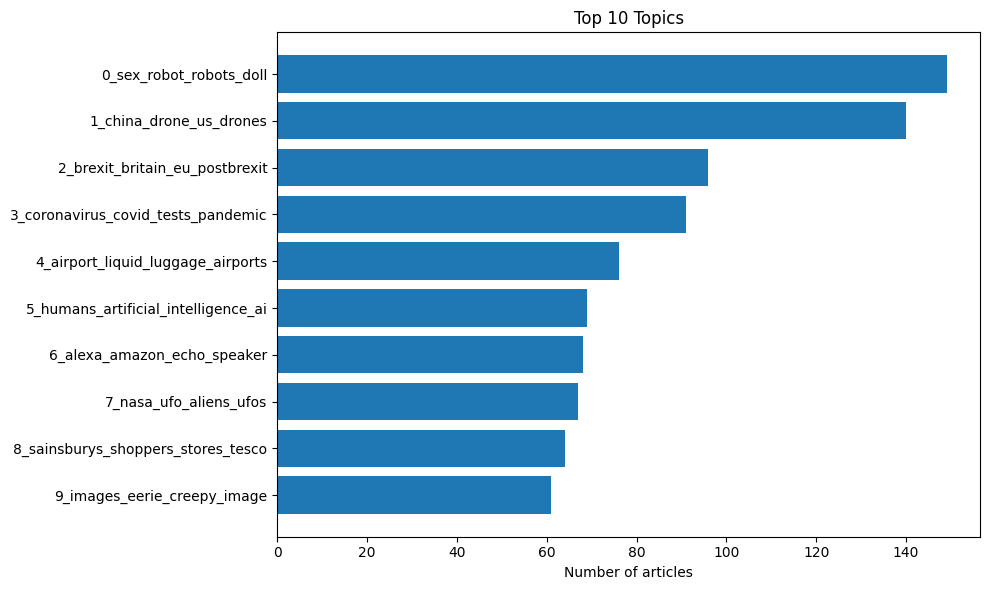

In [27]:
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info['Topic'] != -1].head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(topic_info['Name'], topic_info['Count'])
ax.set_xlabel('Number of articles')
ax.set_title('Top 10 Topics')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
topic_labels = topic_model.generate_topic_labels()
topic_model.set_topic_labels(topic_labels)

In [29]:
topic_labels

['-1_to_in_and',
 '0_sex_robot_robots',
 '1_china_drone_us',
 '2_brexit_britain_eu',
 '3_coronavirus_covid_tests',
 '4_airport_liquid_luggage',
 '5_humans_artificial_intelligence',
 '6_alexa_amazon_echo',
 '7_nasa_ufo_aliens',
 '8_sainsburys_shoppers_stores',
 '9_images_eerie_creepy',
 '10_elon_musk_tesla',
 '11_scammers_scam_web',
 '12_drivers_fine_parking',
 '13_upgrade_samsung_receive',
 '14_putin_vladimir_daughters',
 '15_boeing_fly_passengers',
 '16_var_league_premier',
 '17_firms_record_costs',
 '18_rishi_sunak_joe',
 '19_chatgpt_chatbot_chatbots',
 '20_jobs_job_ai',
 '21_porn_images_girls',
 '22_iphone_ios_16',
 '23_xi_man_utd',
 '24_cops_4yearold_dead',
 '25_mark_glasses_zuckerberg',
 '26_instagram_social_media',
 '27_voice_clones_clone',
 '28_stars_guess_unrecognisable',
 '29_musk_elon_humanity',
 '30_brain_neuralink_elon',
 '31_cancer_breast_slash',
 '32_deals_friday_xs',
 '33_album_song_taylor',
 '34_car_ev_motor',
 '35_cast_season_series',
 '36_ukraine_putin_putins',
 '37_d

In [30]:
topic_model.update_topics(sun['title'], n_gram_range = (1, 3))

In [31]:
topic_model.visualize_heatmap(n_clusters=20)

In [32]:
topic_model.visualize_documents(
    sun['title'],
    topics = list(range(30)),
    custom_labels = True
)